In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load data
df = pd.read_excel(r"C:\Users\hp\Desktop\Data analysis\Projects\financial_data_clean.xlsx", sheet_name='financial_data_clean')
df.head()

,order_id,date,product_id,region,sales_rep,revenue,quantity,category,cost_ratio,cost,profit,profit_margin,year,month,month_name,year_month
0,ORD0001,2023-01-01 00:00:00.000,P004,West,Nour,2874,6,Clothing,0.60,1724.40,1149.60,40,2023,1,Jan,2023-01
1,ORD0002,2023-01-02 07:54:45.246,P005,North,Omar,2996,19,Furniture,0.72,2157.12,838.88,28,2023,1,Jan,2023-01
2,ORD0003,2023-01-03 15:49:30.492,P003,West,Sara,4285,5,Clothing,0.55,2356.75,1928.25,45,2023,1,Jan,2023-01
3,ORD0004,2023-01-04 23:44:15.738,P005,East,Sara,875,4,Furniture,0.72,630.00,245.00,28,2023,1,Jan,2023-01
4,ORD0005,2023-01-06 07:39:00.984,P005,North,Khalid,1725,15,Furniture,0.72,1242.00,483.00,28,2023,1,Jan,2023-01


In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(540, 16)
order_id                 object
date             datetime64[ns]
product_id               object
region                   object
sales_rep                object
revenue                   int64
quantity                  int64
category                 object
cost_ratio              float64
cost                    float64
profit                  float64
profit_margin             int64
year                      int64
month                     int64
month_name               object
year_month               object
dtype: object
order_id         0
date             0
product_id       0
region           0
sales_rep        0
revenue          0
quantity         0
category         0
cost_ratio       0
cost             0
profit           0
profit_margin    0
year             0
month            0
month_name       0
year_month       0
dtype: int64


In [6]:
df = df.drop_duplicates()
df = df.dropna(subset=['revenue'])
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')
df['profit_margin'] = ((df['profit'] / df['revenue']) * 100).round(2)
df

,order_id,date,product_id,region,sales_rep,revenue,quantity,category,cost_ratio,cost,profit,profit_margin,year,month,month_name,year_month
0,ORD0001,2023-01-01 00:00:00.000,P004,West,Nour,2874,6,Clothing,0.60,1724.40,1149.60,40.0,2023,1,Jan,2023-01
1,ORD0002,2023-01-02 07:54:45.246,P005,North,Omar,2996,19,Furniture,0.72,2157.12,838.88,28.0,2023,1,Jan,2023-01
2,ORD0003,2023-01-03 15:49:30.492,P003,West,Sara,4285,5,Clothing,0.55,2356.75,1928.25,45.0,2023,1,Jan,2023-01
3,ORD0004,2023-01-04 23:44:15.738,P005,East,Sara,875,4,Furniture,0.72,630.00,245.00,28.0,2023,1,Jan,2023-01
4,ORD0005,2023-01-06 07:39:00.984,P005,North,Khalid,1725,15,Furniture,0.72,1242.00,483.00,28.0,2023,1,Jan,2023-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,ORD0546,2024-12-25 16:20:59.016,P002,West,Khalid,2222,3,Electronics,0.70,1555.40,666.60,30.0,2024,12,Dec,2024-12
536,ORD0547,2024-12-27 00:15:44.262,P005,South,Ali,485,12,Furniture,0.72,349.20,135.80,28.0,2024,12,Dec,2024-12
537,ORD0548,2024-12-28 08:10:29.508,P003,North,Nour,3381,15,Clothing,0.55,1859.55,1521.45,45.0,2024,12,Dec,2024-12
538,ORD0549,2024-12-29 16:05:14.754,P002,South,Omar,574,9,Electronics,0.70,401.80,172.20,30.0,2024,12,Dec,2024-12


In [ ]:
total_revenue = df['revenue'].sum().round(2)
total_cost = df['cost'].sum().round(2)
total_profit = df['profit'].sum().round(2)
avg_margin = df['profit_margin'].mean().round(2)

print("===== OVERALL KPIs =====")
print(f"Total Revenue: {total_revenue}")
print(f"Total Cost: {total_cost}")
print(f"Total Profit: {total_profit}")
print(f"Total Margin: {avg_margin}")

===== OVERALL KPIs =====
Total Revenue: 1397527
Total Cost: 922419.06
Total Profit: 475107.94
Total Margin: 34.06


In [ ]:
profit_by_category = df.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin', 'mean'),
    order_count=('order_id', 'count')
).round(2).sort_values('total_profit', ascending=False)
profit_by_category

,total_revenue,total_profit,avg_margin,order_count
category,,,,
Clothing,494773,208925.25,42.21,190
Electronics,458156,148747.65,32.64,180
Furniture,444598,117435.04,26.46,170


In [ ]:
profit_by_region = df.groupby('region').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin', 'mean'),
    order_count=('order_id', 'count')
).round(2).sort_values('total_revenue', ascending=False)
profit_by_region

,total_revenue,total_profit,avg_margin,order_count
region,,,,
South,370924,122352.99,33.46,142
North,356352,123343.15,34.17,139
West,346590,118416.06,34.25,133
East,323661,110995.74,34.44,126


In [10]:
profit_by_rep = df.groupby('sales_rep').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    order_count=('order_id', 'count')
).round(2).sort_values('total_profit', ascending=False)
profit_by_rep

,total_revenue,total_profit,order_count
sales_rep,,,
Sara,318052,107665.31,113
Khalid,287750,101226.30,115
Nour,292149,95598.74,118
Ali,260208,92417.97,102
Omar,239368,78199.62,92


In [ ]:
monthly = df.groupby('year_month').agg(
    revenue=('revenue', 'sum'),
    profit=('profit', 'sum')
).round(2)
monthly

,revenue,profit
year_month,,
2023-01,49810,16789.98
2023-02,57086,20484.45
2023-03,62832,21405.81
2023-04,50459,14837.39
2023-05,60785,21514.79
2023-06,62108,21380.87
2023-07,54971,19414.35
2023-08,54113,18522.04
2023-09,69884,24244.62


In [12]:
yearly = df.groupby(df['date'].dt.year).agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    order_count=('order_id', 'count')
).round(2)
yearly

,total_revenue,total_profit,order_count
date,,,
2023,725639,250457.25,270
2024,671888,224650.69,270


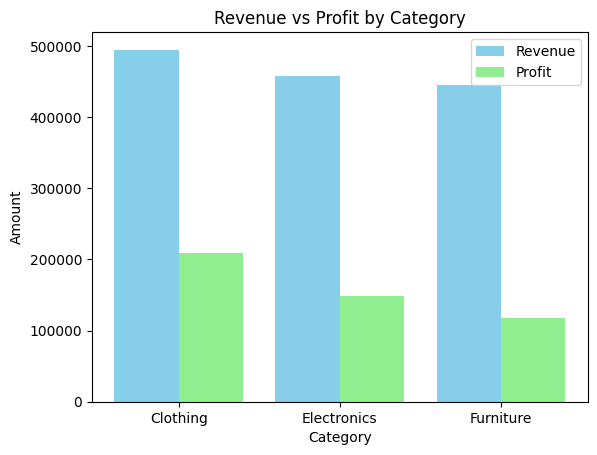

In [13]:
category_data = df.groupby('category')[['revenue','profit']].sum()
x = range(len(category_data))
plt.bar([i - 0.2 for i in x], category_data['revenue'], width=0.4, label='Revenue', color='skyblue')
plt.bar([i + 0.2 for i in x], category_data['profit'], width=0.4, label='Profit', color='lightgreen')
plt.xticks(list(x), category_data.index)
plt.title('Revenue vs Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.legend()
plt.show()

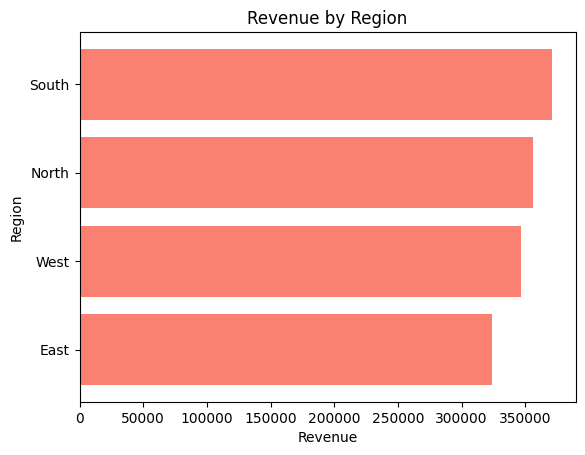

In [ ]:
region_data = df.groupby('region')['revenue'].sum().sort_values()
plt.barh(region_data.index, region_data.values, color='salmon')
plt.title('Revenue by Region')
plt.xlabel('Revenue')
plt.ylabel('Region')
plt.show()

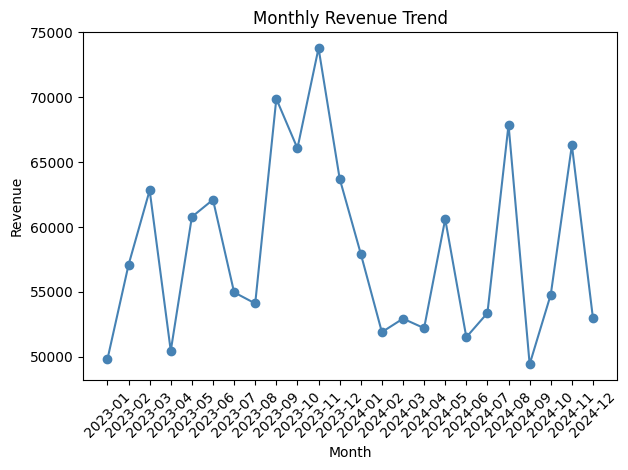

In [ ]:
monthly_data = df.groupby('year_month')['revenue'].sum()
plt.plot(monthly_data.index.astype(str), monthly_data.values, color='steelblue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

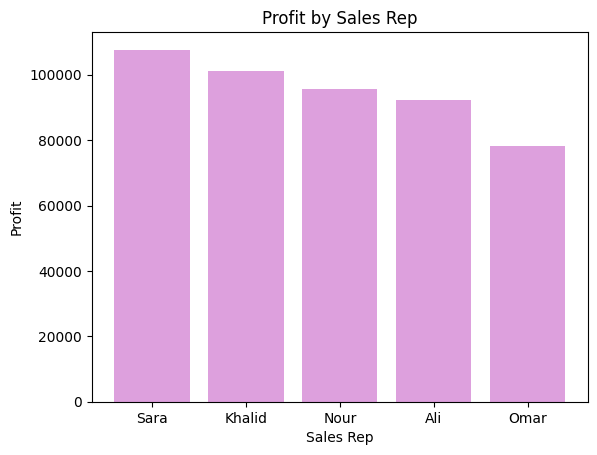

In [16]:
rep_data = df.groupby('sales_rep')['profit'].sum().sort_values(ascending=False)
plt.bar(rep_data.index, rep_data.values, color='plum')
plt.title('Profit by Sales Rep')
plt.xlabel('Sales Rep')
plt.ylabel('Profit')
plt.show()